# Análisis de Comportamiento de Ordes y Clientes — Brazilian E-Commerce Public Dataset by Olist

**Summary:** Este es un conjunto de datos público de comercio electrónico brasileño de pedidos realizados en Olist Store. Contiene información de 100.000 pedidos realizados entre 2016 y 2018 en varios marketplaces de Brasil. Estos son datos comerciales reales, han sido anonimizados, para que los datos puedan trabajarse publicamente en la plataforma kaggle

**Autor:** Rodolfo Gabriel Riveros Lobos | **Fecha:** 27/04/2026  
**Objetivo:** Analicis CX sobre ordenes y clientes, Promotores, Gaps entre ventas y satisfacción. Conclusiones finales ofreciendo acciones de mejora.

### 1. Obtener la clave de API de Kaggle

1.  Ve a [Kaggle](https://www.kaggle.com/).
2.  Haz clic en tu **imagen de perfil** en la esquina superior derecha y selecciona **'Your Profile'**.
3.  Haz clic en **'Account'** en el menú de la izquierda.
4.  Desplázate hacia abajo hasta la sección **'API'** y haz clic en **'Create New API Token'**. Esto descargará un archivo `kaggle.json` a tu computadora.

### 2. Subir `kaggle.json` a Colab

Para usar la API de Kaggle, necesitas subir el archivo `kaggle.json` a Colab. Una forma sencilla es subirlo directamente a la carpeta `/root/.kaggle/`.

In [5]:
from google.colab import files
import os

# Crear el directorio .kaggle si no existe
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

# Subir kaggle.json
print('Por favor, sube tu archivo kaggle.json:')
uploaded = files.upload()

for fn in uploaded.keys():
    # Mover el archivo a la ubicación correcta
    os.rename(fn, '/root/.kaggle/' + fn)
    # Establecer permisos adecuados
    os.chmod('/root/.kaggle/' + fn, 600)
    print(f'Archivo {fn} subido y configurado correctamente.')

Por favor, sube tu archivo kaggle.json:


### 3. Instalar la librería Kaggle y descargar el dataset

Ahora puedes instalar la librería de Kaggle y usarla para descargar el dataset. El dataset que causó el error `FileNotFoundError` fue 'olistbr/brazilian-ecommerce'.

In [6]:
# Instalar la librería de Kaggle
!pip install kaggle

# Descargar el dataset (el nombre del dataset se obtiene de la ruta original)
kaggle_dataset_name = 'olistbr/brazilian-ecommerce'
!kaggle datasets download -d {kaggle_dataset_name}

# Descomprimir los archivos
# El archivo zip descargado tendrá el mismo nombre que el dataset, pero con '_dataset.zip'
zip_file_name = kaggle_dataset_name.split('/')[-1] + '.zip'
!unzip -o {zip_file_name} -d brazilian-ecommerce

print(f'Dataset {kaggle_dataset_name} descargado y descomprimido en la carpeta brazilian-ecommerce/')

# Listar los archivos para verificar
!ls brazilian-ecommerce/

Dataset URL: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce
License(s): CC-BY-NC-SA-4.0
brazilian-ecommerce.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  brazilian-ecommerce.zip
  inflating: brazilian-ecommerce/olist_customers_dataset.csv  
  inflating: brazilian-ecommerce/olist_geolocation_dataset.csv  
  inflating: brazilian-ecommerce/olist_order_items_dataset.csv  
  inflating: brazilian-ecommerce/olist_order_payments_dataset.csv  
  inflating: brazilian-ecommerce/olist_order_reviews_dataset.csv  
  inflating: brazilian-ecommerce/olist_orders_dataset.csv  
  inflating: brazilian-ecommerce/olist_products_dataset.csv  
  inflating: brazilian-ecommerce/olist_sellers_dataset.csv  
  inflating: brazilian-ecommerce/product_category_name_translation.csv  
Dataset olistbr/brazilian-ecommerce descargado y descomprimido en la carpeta brazilian-ecommerce/
olist_customers_dataset.csv	  olist_orders_dataset.csv
olist_geolocation_dat

### 4. Actualizar el `base_path` en la celda original

Ahora que los archivos están descargados y descomprimidos en la carpeta `brazilian-ecommerce/`, necesitas actualizar el `base_path` en la celda original (`H5B3pfBsE2G-`) para que apunte a esta nueva ubicación local. Ejecutaré la celda modificada para ti.

In [9]:
import pandas as pd

# Se actualiza la ruta base a la ubicación donde se descomprimió el dataset
base_path = "./brazilian-ecommerce/"

orders = pd.read_csv(base_path + "olist_orders_dataset.csv")
customers = pd.read_csv(base_path + "olist_customers_dataset.csv")
payments = pd.read_csv(base_path + "olist_order_payments_dataset.csv")
reviews = pd.read_csv(base_path + "olist_order_reviews_dataset.csv")

print("Datasets cargados exitosamente!")
print("Primeras 5 filas de 'orders':")
display(orders.head())
print("Primeras 5 filas de 'customers':")
display(customers.head())
print("Primeras 5 filas de 'payments':")
display(payments.head())
print("Primeras 5 filas de 'reviews':")
display(reviews.head())

Datasets cargados exitosamente!
Primeras 5 filas de 'orders':


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


Primeras 5 filas de 'customers':


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Primeras 5 filas de 'payments':


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Primeras 5 filas de 'reviews':


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


#Importanto Librerías de trabajo

In [8]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una base de datos para trabajar con SQLite

In [12]:
# Creando base de datos en memoria
conn = sqlite3.connect('olist.db')

# Define la ruta base donde se encuentran los archivos CSV
base_path = './brazilian-ecommerce/'

try:
    # Cargar las tablas que vas a usar, usando la ruta base
    orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')
    order_items = pd.read_csv(base_path + 'olist_order_items_dataset.csv')
    order_reviews = pd.read_csv(base_path + 'olist_order_reviews_dataset.csv')
    customers = pd.read_csv(base_path + 'olist_customers_dataset.csv')

    # Escribir en SQLite
    orders.to_sql('orders', conn, if_exists='replace', index=False)
    order_items.to_sql('order_items', conn, if_exists='replace', index=False)
    order_reviews.to_sql('order_reviews', conn, if_exists='replace', index=False)
    customers.to_sql('customers', conn, if_exists='replace', index=False)

    print('✅ Base de datos cargada correctamente')
except Exception as e:
    print(f'❌ Ocurrió un error al cargar la base de datos: {e}')

✅ Base de datos cargada correctamente


#Analizando Ordenes
## ¿Cuantas Ordes por estado existen?

In [13]:
QUERY1 = """
SELECT
    order_status,
    COUNT(*) AS total_ordenes,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS porcentaje
FROM orders
GROUP BY order_status
ORDER BY total_ordenes DESC
"""

df_status = pd.read_sql_query(QUERY1, conn)
print(df_status)

  order_status  total_ordenes  porcentaje
0    delivered          96478       97.02
1      shipped           1107        1.11
2     canceled            625        0.63
3  unavailable            609        0.61
4     invoiced            314        0.32
5   processing            301        0.30
6      created              5        0.01
7     approved              2        0.00


In [34]:
#Ranking de revenue por estado dentro de cada categoría
QUERY1_1 = """
SELECT
    customer_state,
    order_status,
    COUNT(*) AS total,
    RANK() OVER (PARTITION BY order_status ORDER BY COUNT(*) DESC) AS ranking
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY customer_state, order_status
ORDER BY order_status, total DESC
"""

df_ranking = pd.read_sql_query(QUERY1_1, conn)
print(df_ranking)

    customer_state order_status  total  ranking
0               MG     approved      1        1
1               SP     approved      1        1
2               SP     canceled    327        1
3               RJ     canceled     86        2
4               MG     canceled     64        3
..             ...          ...    ...      ...
144             PA  unavailable      2       20
145             AL  unavailable      1       21
146             AM  unavailable      1       21
147             PI  unavailable      1       21
148             TO  unavailable      1       21

[149 rows x 4 columns]


### Ranking de Estados por Estado de Orden

Un ranking de los estados de los clientes por el número de órdenes dentro de cada estado de orden (`delivered`, `canceled`, etc.).

*   **Identificación Rápida:** Permite ver qué estados lideran en cada categoría de estado de orden, sean positivos (ej. 'delivered') o negativos (ej. 'canceled', 'unavailable').
*   **Foco en Áreas Clave:** Señala dónde se concentran problemas o éxitos, ayudando a priorizar la atención y los recursos en regiones específicas.
*   **Monitoreo Regional:** Sirve para detectar cambios de rendimiento en estados clave, indicando tendencias que requieren investigación.

In [37]:
QUERY2 = """
SELECT
     SUBSTR(o.order_purchase_timestamp, 1, 7) AS mes,
     COUNT(DISTINCT o.order_id) AS total_ordenes,
     ROUND(SUM(oi.price), 2) AS revenue_total,
     ROUND(AVG(oi.price), 2) AS ticket_promedio
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'
GROUP BY mes
ORDER BY mes
"""
df_revenue = pd.read_sql_query(QUERY2, conn)
print(df_revenue.tail(10))

        mes  total_ordenes  revenue_total  ticket_promedio
13  2017-11           7289      987765.37           116.55
14  2017-12           5513      726033.19           117.35
15  2018-01           7069      924645.00           115.05
16  2018-02           6555      826437.13           109.93
17  2018-03           7003      953356.25           118.92
18  2018-04           6798      973534.09           124.38
19  2018-05           6749      977544.69           125.17
20  2018-06           6099      856077.86           122.12
21  2018-07           6159      867953.46           124.65
22  2018-08           6351      838576.64           117.41


## Porcentaje de Órdenes No Entregadas

In [16]:
porcentaje_delivered = df_status[df_status['order_status'] == 'delivered']['porcentaje'].iloc[0]
porcentaje_no_entregadas = 100 - porcentaje_delivered

print(f"El porcentaje de órdenes que NO llegaron entregadas es: {porcentaje_no_entregadas:.2f}%")

El porcentaje de órdenes que NO llegaron entregadas es: 2.98%


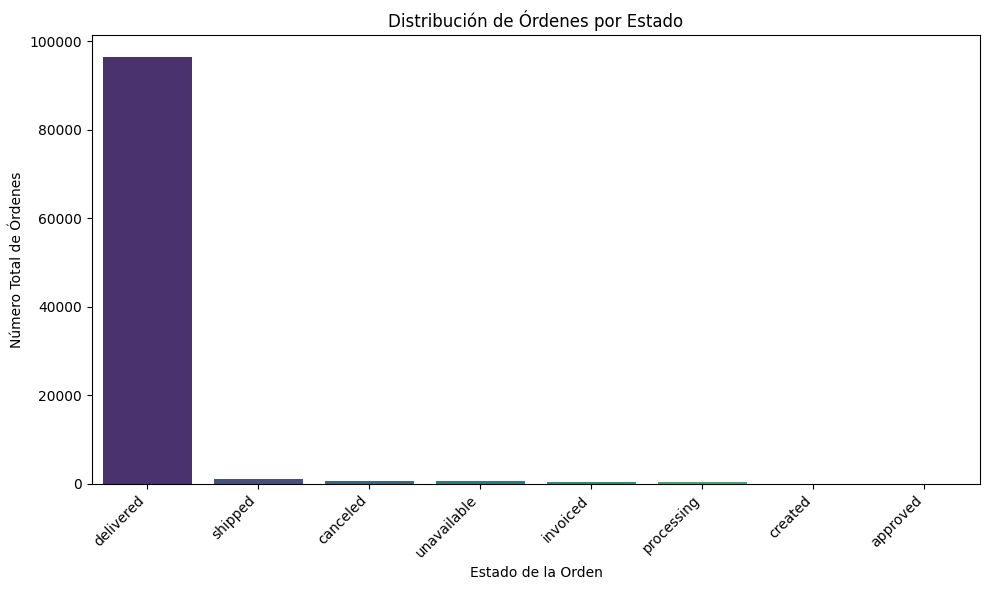

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x='order_status', y='total_ordenes', data=df_status, hue='order_status', palette='viridis', legend=False)
plt.title('Distribución de Órdenes por Estado')
plt.xlabel('Estado de la Orden')
plt.ylabel('Número Total de Órdenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Analizando Ticket Promedio y Ganancias por mes

## Visualización de Tendencia de Revenue Mensual

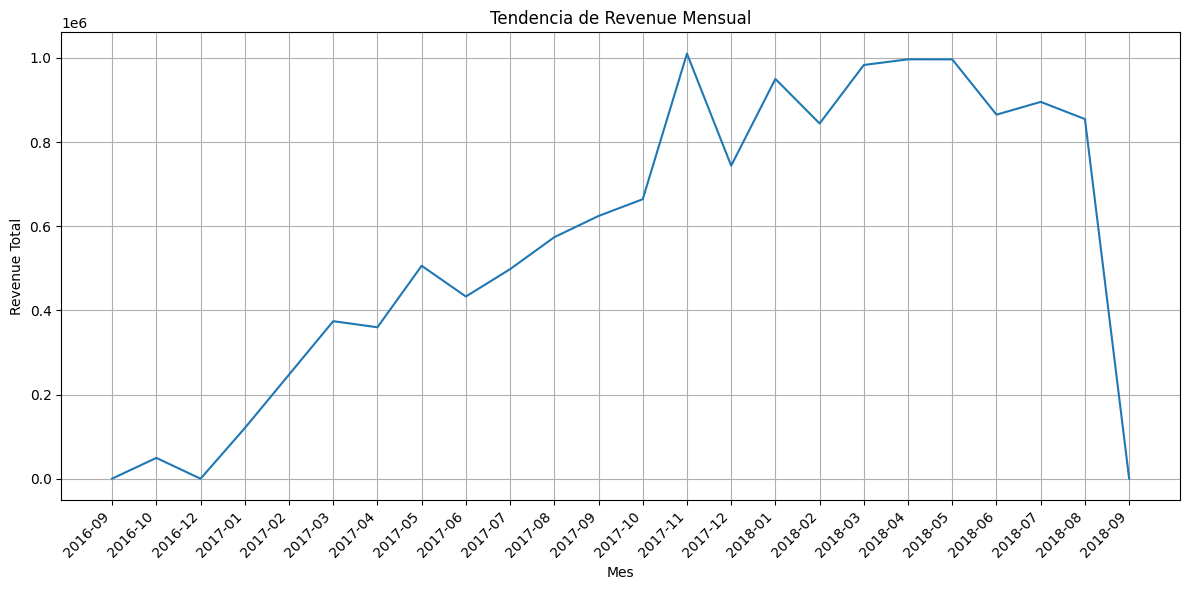

In [19]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='mes', y='revenue_total', data=df_revenue)
plt.title('Tendencia de Revenue Mensual')
plt.xlabel('Mes')
plt.ylabel('Revenue Total')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

## ¿Hay estacionalidad visible en la tendencia de revenue mensual?

### Análisis Visual de la Tendencia de Revenue Mensual

Al observar el gráfico de "Tendencia de Revenue Mensual", podemos identificar los siguientes patrones:

*   **Crecimiento General:** A lo largo del periodo visible, se aprecia una tendencia general ascendente en la revenue total.
*   **Picos Notables:** Existen picos de revenue significativos hacia el final de cada año, siendo el de noviembre de 2017 particularmente pronunciado. Otro pico importante se observa en mayo de 2018.
*   **Valles o Caídas:** Se aprecian descensos en la revenue en ciertos meses, como en febrero de 2017 y 2018, y también en los meses de junio, julio y agosto de 2018. El inicio de 2017 también muestra valores más bajos en comparación con el resto del año.
*   **Comportamiento Anual:** Los meses de final de año (octubre, noviembre) consistentemente muestran los niveles más altos de revenue, mientras que los primeros meses del año (enero, febrero) y la mitad del año (junio, julio, agosto) tienden a registrar valores más bajos.

#Analizando Net Promotor Score - Distribución de reviews scores

In [20]:
QUERY3 = """
SELECT
     r.review_score,
     COUNT(*) AS total_reviews,
     ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS porcentaje
FROM order_reviews r
JOIN orders o ON r.order_id = o.order_id
WHERE o.order_status = 'delivered'
GROUP BY r.review_score
ORDER BY r.review_score
"""

df_reviews = pd.read_sql_query(QUERY3, conn)
print(df_reviews)

   review_score  total_reviews  porcentaje
0             1           9406        9.76
1             2           2941        3.05
2             3           7961        8.26
3             4          18987       19.70
4             5          57066       59.22


## Estimación de NPS

### Explicación de la Estimación del Net Promoter Score (NPS)

El Net Promoter Score (NPS) es una métrica de lealtad del cliente que se calcula basándose en las respuestas a la pregunta: "¿Qué probabilidad hay de que recomiende esta empresa/producto/servicio a un amigo o colega?". Adaptando esta metodología a nuestra escala de reviews de 1 a 5, las respuestas se agrupan comúnmente en tres categorías:

*   **Promotores:** Clientes que dan una puntuación de 4 o 5. Son entusiastas leales que seguirán comprando y recomendarán a otros, impulsando el crecimiento.
*   **Pasivos (Neutros):** Clientes que dan una puntuación de 3. Son clientes satisfechos pero no entusiastas, y pueden ser vulnerables a las ofertas de la competencia.
*   **Detractores:** Clientes que dan una puntuación de 1 o 2. Son clientes insatisfechos que pueden dañar la marca y obstaculizar el crecimiento a través del boca a boca negativo.

### La fórmula para calcular el NPS es simple:

**NPS = % Promotores - % Detractores**



In [38]:
# # Promotores = 4-5 | Detractores = 1-2

promotores_porcentaje = df_reviews[df_reviews['review_score'] >= 4]['porcentaje'].sum()
detractores_porcentaje = df_reviews[df_reviews['review_score'] <= 2]['porcentaje'].sum()
nps = round(promotores_porcentaje - detractores_porcentaje, 2)

print(f"NPS estimado (adaptación escala 1-5): {nps} puntos")
print("⚠️  Metodología: Promotores = scores 4-5 | Detractores = scores 1-2")
print("    No equivalente a NPS estándar (escala 0-10). Útil como proxy operativo.")

NPS estimado (adaptación escala 1-5): 66.11 puntos
⚠️  Metodología: Promotores = scores 4-5 | Detractores = scores 1-2
    No equivalente a NPS estándar (escala 0-10). Útil como proxy operativo.



### Resultado: Clientes leales que seguiran comprando representan el 66.11%

### Nota:
Es importante recordar que, si bien estos benchmarks son útiles como guía general, el NPS ideal puede variar según la industria, la región y el modelo de negocio. La clave es compararse con competidores directos y, más importante aún, con el propio rendimiento histórico para identificar tendencias y áreas de mejora.


# Top 10 estados con más órdenes y su review score promedio

In [27]:
QUERY4 = """
SELECT
     c.customer_state,
     COUNT(DISTINCT o.order_id) AS total_ordenes,
     ROUND(AVG(r.review_score), 2) AS review_score_promedio
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN order_reviews r ON o.order_id = r.order_id
GROUP BY c.customer_state
ORDER BY total_ordenes DESC
LIMIT 10
"""
df_estados = pd.read_sql_query(QUERY4, conn)
display(df_estados)

,customer_state,total_ordenes,review_score_promedio
0,SP,41472,4.17
1,RJ,12687,3.87
2,MG,11554,4.14
3,RS,5443,4.13
4,PR,5019,4.18
5,SC,3609,4.07
6,BA,3340,3.86
7,DF,2128,4.06
8,GO,2007,4.04
9,ES,2006,4.04


## Visualización: Órdenes y Score Promedio por Estado

Analicemos la relación entre el volumen de órdenes y la satisfacción del cliente a nivel estatal.

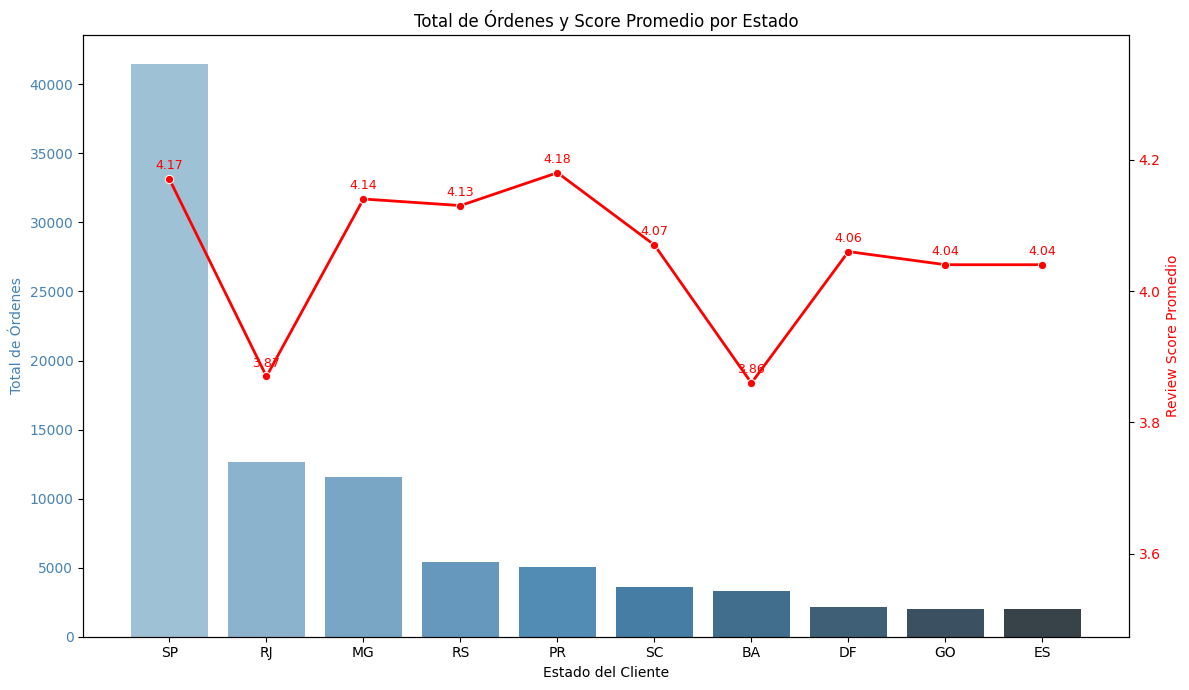

In [32]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# Barras para el total de órdenes
sns.barplot(x='customer_state', y='total_ordenes', data=df_estados, ax=ax1, palette='Blues_d', hue='customer_state', legend=False)
ax1.set_xlabel('Estado del Cliente')
ax1.set_ylabel('Total de Órdenes', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_title('Total de Órdenes y Score Promedio por Estado')

# Crear un segundo eje Y para el review_score_promedio
ax2 = ax1.twinx()
sns.lineplot(x='customer_state', y='review_score_promedio', data=df_estados, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Review Score Promedio', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(df_estados['review_score_promedio'].min() * 0.9, df_estados['review_score_promedio'].max() * 1.05) # Ajustar límites para mejor visualización

# Añadir anotaciones para el review score promedio
for index, row in df_estados.iterrows():
    ax2.annotate(f'{row['review_score_promedio']:.2f}',
                 xy=(index, row['review_score_promedio']),
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='bottom', color='red', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### ¿Los estados con más volumen tienen mejor o peor experiencia?

Al observar el gráfico de barras doble que compara el total de órdenes con el puntaje promedio de reviews por estado, podemos sacar algunas conclusiones:

*   **Relación General:** No hay una correlación negativa directa evidente. Los estados con el mayor volumen de órdenes, como **SP (São Paulo)**, no presentan necesariamente un promedio de review score más bajo. De hecho, SP tiene un score promedio bastante alto (4.17), lo que indica que, a pesar del gran volumen, mantienen una buena satisfacción del cliente.

*   **Estados con Alto Volumen y Buen Score:** Estados como **SP, MG (Minas Gerais), y PR (Paraná)** muestran un alto volumen de órdenes y, al mismo tiempo, puntajes de review score por encima del promedio, lo cual es un indicador muy positivo de eficiencia y calidad a gran escala.

*   **Estados con Alto Volumen y Ligeramente Menor Score:** **RJ (Río de Janeiro)** y **BA (Bahía)**, aunque tienen un volumen de órdenes considerable, muestran un `review_score_promedio` ligeramente inferior en comparación con otros estados de alto volumen. Esto podría sugerir áreas de mejora en la experiencia del cliente en estas regiones, a pesar de tener una base de clientes activa.

*   **Consistencia de Score:** En general, la mayoría de los top 10 estados mantienen un `review_score_promedio` relativamente alto (por encima de 3.8), lo que sugiere una base de clientes mayoritariamente satisfecha en las regiones con mayor actividad comercial.

En resumen, el volumen no parece ser un impedimento para una buena experiencia del cliente. Sin embargo, hay matices entre los estados que podrían ser explorados para entender las variaciones en la satisfacción del cliente.

## Visualización en Mapa: Órdenes y Satisfacción por Estado

Para crear una visualización geográfica, primero necesitamos datos geoespaciales de los estados de Brasil. Utilizaremos un archivo GeoJSON público que contiene las geometrías de los estados.

In [28]:
# Instalar geopandas si no está instalado
!pip install geopandas matplotlib

import geopandas as gpd
import matplotlib.pyplot as plt

# URL de un archivo GeoJSON de estados de Brasil
# Fuente: Puedes encontrar estos archivos en repositorios públicos de datos geográficos
geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"

# Cargar el archivo GeoJSON
brazil_states = gpd.read_file(geojson_url)

print("Datos geoespaciales de Brasil cargados exitosamente.")
display(brazil_states.head())

Datos geoespaciales de Brasil cargados exitosamente.


,id,name,sigla,regiao_id,codigo_ibg,cartodb_id,created_at,updated_at,geometry
0,1,Acre,AC,3,12,1,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-73.60818 -7.20194, -72.86963 ..."
1,2,Alagoas,AL,4,27,2,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-35.46516 -8.82549, -35.46626 ..."
2,3,Amazonas,AM,3,13,3,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-67.32553 2.03012, -67.32234 2..."
3,4,Amapá,AP,3,16,4,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-51.18168 4.00889, -51.179 3.9..."
4,5,Bahia,BA,4,29,5,2015-02-09 16:46:01+00:00,2015-02-09 16:46:01+00:00,"MULTIPOLYGON (((-39.2882 -8.5629, -39.28229 -8..."


Ahora que tenemos los datos geoespaciales, necesitamos fusionarlos con nuestro `df_estados` que contiene `total_ordenes` y `review_score_promedio`. Es importante que la columna de los estados en ambos DataFrames coincida para poder realizar la unión correctamente.

También necesitamos definir una métrica combinada para "Órdenes + Score". Para que ambas métricas contribuyan de manera equitativa a la intensidad del color, primero las normalizaremos entre 0 y 1, y luego las multiplicaremos o sumaremos. La multiplicación tiende a acentuar las áreas donde ambos valores son altos, mientras que la suma da más peso a los valores individuales. Empecemos con una métrica multiplicativa después de la normalización.

In [35]:
# Renombrar la columna 'name' en brazil_states para que coincida con 'customer_state' en df_estados
brazil_states_merged = brazil_states.rename(columns={'name': 'customer_state'})

# La columna 'customer_state' en df_estados tiene las siglas de los estados (SP, RJ, MG, etc.)
# Necesitamos mapear los nombres completos de los estados a sus siglas para la unión.
# Crear un diccionario de mapeo de nombres completos a siglas (ej. 'São Paulo' -> 'SP')

state_name_to_abbr = {
    'Amazonas': 'AM', 'Roraima': 'RR', 'Amapá': 'AP', 'Pará': 'PA', 'Tocantins': 'TO',
    'Rondônia': 'RO', 'Acre': 'AC', 'Maranhão': 'MA', 'Piauí': 'PI', 'Ceará': 'CE',
    'Rio Grande do Norte': 'RN', 'Paraíba': 'PB', 'Pernambuco': 'PE', 'Alagoas': 'AL',
    'Sergipe': 'SE', 'Bahia': 'BA', 'Minas Gerais': 'MG', 'Espírito Santo': 'ES',
    'Rio de Janeiro': 'RJ', 'São Paulo': 'SP', 'Paraná': 'PR', 'Santa Catarina': 'SC',
    'Rio Grande do Sul': 'RS', 'Mato Grosso do Sul': 'MS', 'Mato Grosso': 'MT',
    'Goiás': 'GO', 'Distrito Federal': 'DF'
}

# Crear una columna de siglas en brazil_states_merged
brazil_states_merged['state_abbr'] = brazil_states_merged['customer_state'].map(state_name_to_abbr)

# Unir los datos geoespaciales con nuestro DataFrame de estados
# Usamos 'state_abbr' del GeoDataFrame y 'customer_state' del df_estados
geodata = brazil_states_merged.merge(df_estados, left_on='state_abbr', right_on='customer_state', how='left')

# Normalizar 'total_ordenes' y 'review_score_promedio'
geodata['normalized_total_ordenes'] = (geodata['total_ordenes'] - geodata['total_ordenes'].min()) / (geodata['total_ordenes'].max() - geodata['total_ordenes'].min())
geodata['normalized_review_score'] = (geodata['review_score_promedio'] - geodata['review_score_promedio'].min()) / (geodata['review_score_promedio'].max() - geodata['review_score_promedio'].min())

# Crear la métrica combinada: multiplicamos las normalizadas para que ambos contribuyan
geodata['combined_score'] = (
    geodata['normalized_total_ordenes'] * geodata['normalized_review_score']
)

#Verificando resultado
print("✅ combined_score calculado")
print(geodata[['state_abbr', 'total_ordenes', 'review_score_promedio', 'combined_score']].dropna().head(10))


✅ combined_score calculado
   state_abbr  total_ordenes  review_score_promedio  combined_score
4          BA         3340.0                   3.86        0.000000
6          ES         2006.0                   4.04        0.000000
7          GO         2007.0                   4.04        0.000014
9          MG        11554.0                   4.14        0.211689
16         PR         5019.0                   4.18        0.076344
17         RJ        12687.0                   3.87        0.008457
21         RS         5443.0                   4.13        0.073480
22         SC         3609.0                   4.07        0.026655
24         SP        41472.0                   4.17        0.968750
26         DF         2128.0                   4.06        0.001932


Ahora, crearemos un mapa coroplético donde la intensidad del color de cada estado reflejará el `combined_score`. Cuanto mayor sea el score combinado, más oscuro será el color del estado.

/tmp/ipykernel_896/1539564242.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  for x, y, label in zip(geodata.geometry.centroid.x, geodata.geometry.centroid.y, geodata['state_abbr']):


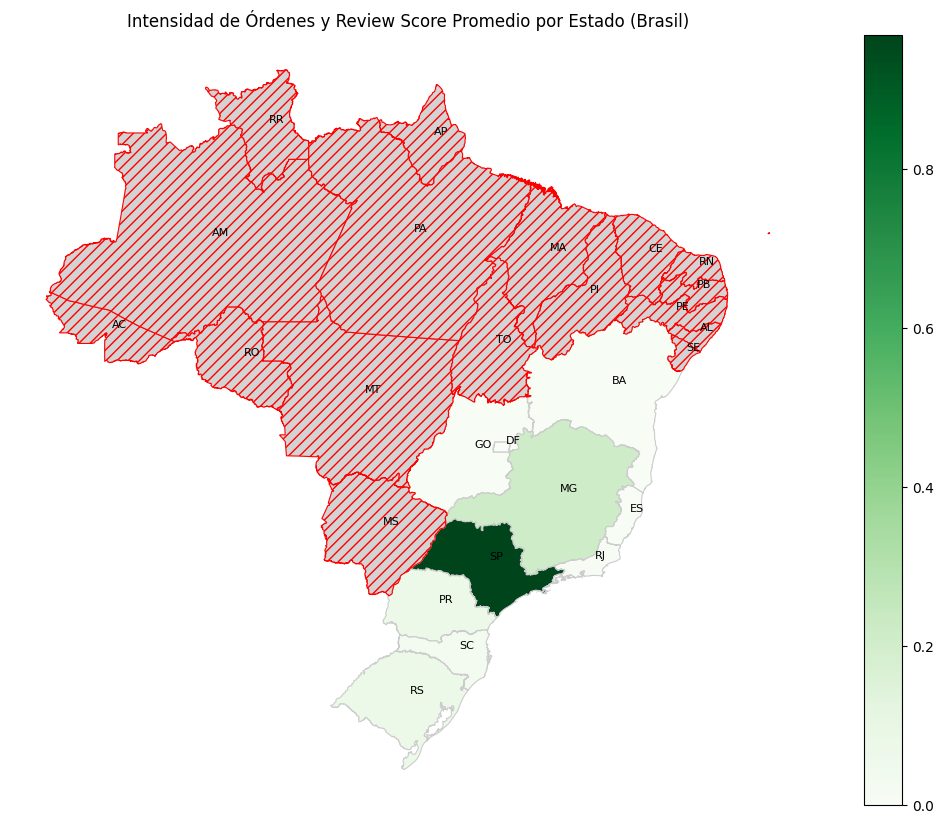

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Usamos 'Greens' para que los colores más intensos representen un "mejor" rendimiento
geodata.plot(column='combined_score',
             cmap='Greens',
             linewidth=0.8,
             ax=ax,
             edgecolor='0.8',
             legend=True,
             missing_kwds={
                 "color": "lightgrey",
                 "edgecolor": "red",
                 "hatch": "///",
                 "label": "No Data",
             })

# Añadir el nombre de los estados en el mapa
for x, y, label in zip(geodata.geometry.centroid.x, geodata.geometry.centroid.y, geodata['state_abbr']):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points", fontsize=8)

ax.set_title('Intensidad de Órdenes y Review Score Promedio por Estado (Brasil)')
ax.set_axis_off()
plt.show()

# Conclusiones - Primera Etapa de Análisis CX

Como Analista de CX, presento las siguientes conclusiones basadas en esta primera etapa exploratoria:

*   **NPS Operativo del Negocio:** El NPS estimado del negocio es del **66.11%**. Este valor se considera **excelente** y sugiere una base de clientes mayoritariamente leal y satisfecha (Promotores) a nivel general.

*   **Detección de un Posible Gap entre Volumen y Satisfacción en Río de Janeiro (RJ):** Al observar el gráfico de órdenes y score promedio por estado, el estado de **Río de Janeiro (RJ)** presenta un volumen de órdenes considerable (el segundo más alto entre los top 10) pero su `review_score_promedio` de 3.87 es el más bajo o de los más bajos entre los estados con alto volumen. Esta es una señal de alerta que indica un **posible gap** donde, a pesar de tener muchos clientes, la experiencia promedio es relativamente menos satisfactoria en comparación con estados de volumen similar o incluso menor. Esta observación, a primera vista, justifica una investigación más profunda.

*   **Recomendación para el Gerente de Operaciones**
Se recomienda **priorizar acciones de mejora en la experiencia de entrega en Río de Janeiro (RJ)**, enfocándose en:

- Reducción de tiempos de entrega  
- Mejora en la calidad del servicio logístico  
- Monitoreo específico de pedidos demorados en la región  

En paralelo, se sugiere realizar un análisis de causas raíz para identificar los factores específicos que afectan la satisfacción, incluyendo:

- Evaluación de transportistas  
- Análisis de incidencias logísticas  
- Análisis de comentarios de clientes (NLP)  

Dado su alto volumen, cualquier mejora en RJ tendrá un impacto significativo en el NPS global del negocio.